In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, CairoMakie, FHist
using Distributions, Statistics, SpecialFunctions
using JLD2, CSV
using LsqFit, QuadGK

In [3]:
include("./utils.jl")
using .Utils

In [4]:
# @load "./Data/processed/microbiome.jld2" MICROBIOME;
@load "./Data/processed/genetic.jld2" GENETIC;
# @load "./Data/processed/books.jld2" BOOKS;
# @load "./Data/processed/mobility.jld2" MOBILITY;
# @load "./Data/processed/null_model.jld2" NULL_MODEL;

In [5]:
Utils.df_filter!(GENETIC; min_samples=5e1, min_nreads=1e4);

# MAD

In [21]:
cutoffs_microbiome = Dict("SLUDGE" => exp(-18.8), "LAKE" => exp(-17.0), "RIVER" => exp(-17.5), "GUT" => exp(-17.5), "GLACIER" => exp(-16.25), "SEAWATER" => exp(-17.9),
    "SOIL" => exp(-14.25), "ORAL" => exp(-16.1), "VAGINAL" => exp(-Inf), "FECES" => exp(-Inf), "AQUA1" => exp(-17), "AQUA2" => exp(-Inf), "ORALCAVITY" => exp(-14.0), "SKIN" => exp(-Inf));

cutoffs_genetic = Dict("BRAIN" => exp(-13), "HEART" => exp(-13), "LIVER" => exp(-13), "PANCREAS" => exp(-13));

cutoffs_books = Dict("ANIMALS" => exp(-17), "GEOGRAPHY" => exp(-17), "CHILDREN" => exp(-17), "ND" => exp(-16), "FICTION" => exp(-16));

cutoffs_mobility = Dict("CHECK-IN" => exp(-16.0));

In [22]:
out = Utils.compute_MAD(GENETIC; c=cutoffs_genetic, bins=30, plot=false, verbose=true, save=true, filename="./Data/MAD/genetic_mad_c");

BRAIN
HEART
LIVER
PANCREAS


In [26]:
@load "./Data/MAD/microbiome_mad_c.jld2" mad_out
microbiome_mad = deepcopy(mad_out)

@load "./Data/MAD/genetic_mad_c.jld2" mad_out
genetic_mad = deepcopy(mad_out)

@load "./Data/MAD/books_mad_c.jld2" mad_out
books_mad = deepcopy(mad_out)

@load "./Data/MAD/mobility_mad_c.jld2" mad_out
mobility_mad = deepcopy(mad_out)

@load "./Data/MAD/null_mad.jld2" mad_out
null_mad = deepcopy(mad_out)

mad_out = nothing
MADs = [microbiome_mad, genetic_mad, books_mad, mobility_mad];#, null_mad];

In [27]:
fig = Figure(size=(1300,500))
ax  = Axis(fig[1, 1];
        yscale=log10, limits=((-5,5),(1e-10,1e1)),
        xlabel = "z", ylabel = "pdf", 
        title = "MAD")

# markers and colors
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :white)

# Prepare separate lists for data and theory
data_plots   = Plot[]       # will hold scatter objects
data_labels  = String[]
env_labels = ["M", "G", "B", "M", "Null"]

for (j,mad) in enumerate(MADs)
    for (i,key) in enumerate(keys(mad))
        x, y = mad[key]
        sc = scatter!(ax, x, 10 .^ log.(y),
                    label=env_labels[j],
                    color=colors[j],
                    marker=shapes[i],
                    markersize=15,
                    strokewidth = 0.8,
                    strokecolor = :black)
        push!(data_plots, sc)
        push!(data_labels, "$(env_labels[j]) $key")
    end
end

zrange = -4:0.01:4
l3 = lines!(ax, zrange, 10 .^ Utils.lrln(zrange, 1); color=:red, linewidth=2.5, label="")
push!(data_plots, l3); push!(data_labels, "rescaled lognormal")

leg_data = Legend(fig, data_plots, data_labels;
    title        = "Data",
    orientation  = :vertical,
    nbanks = 2,
    # shrink the label and title fonts
    labelsize    = 12,
    titlesize    = 12,
)

fig[1, 2] = leg_data;

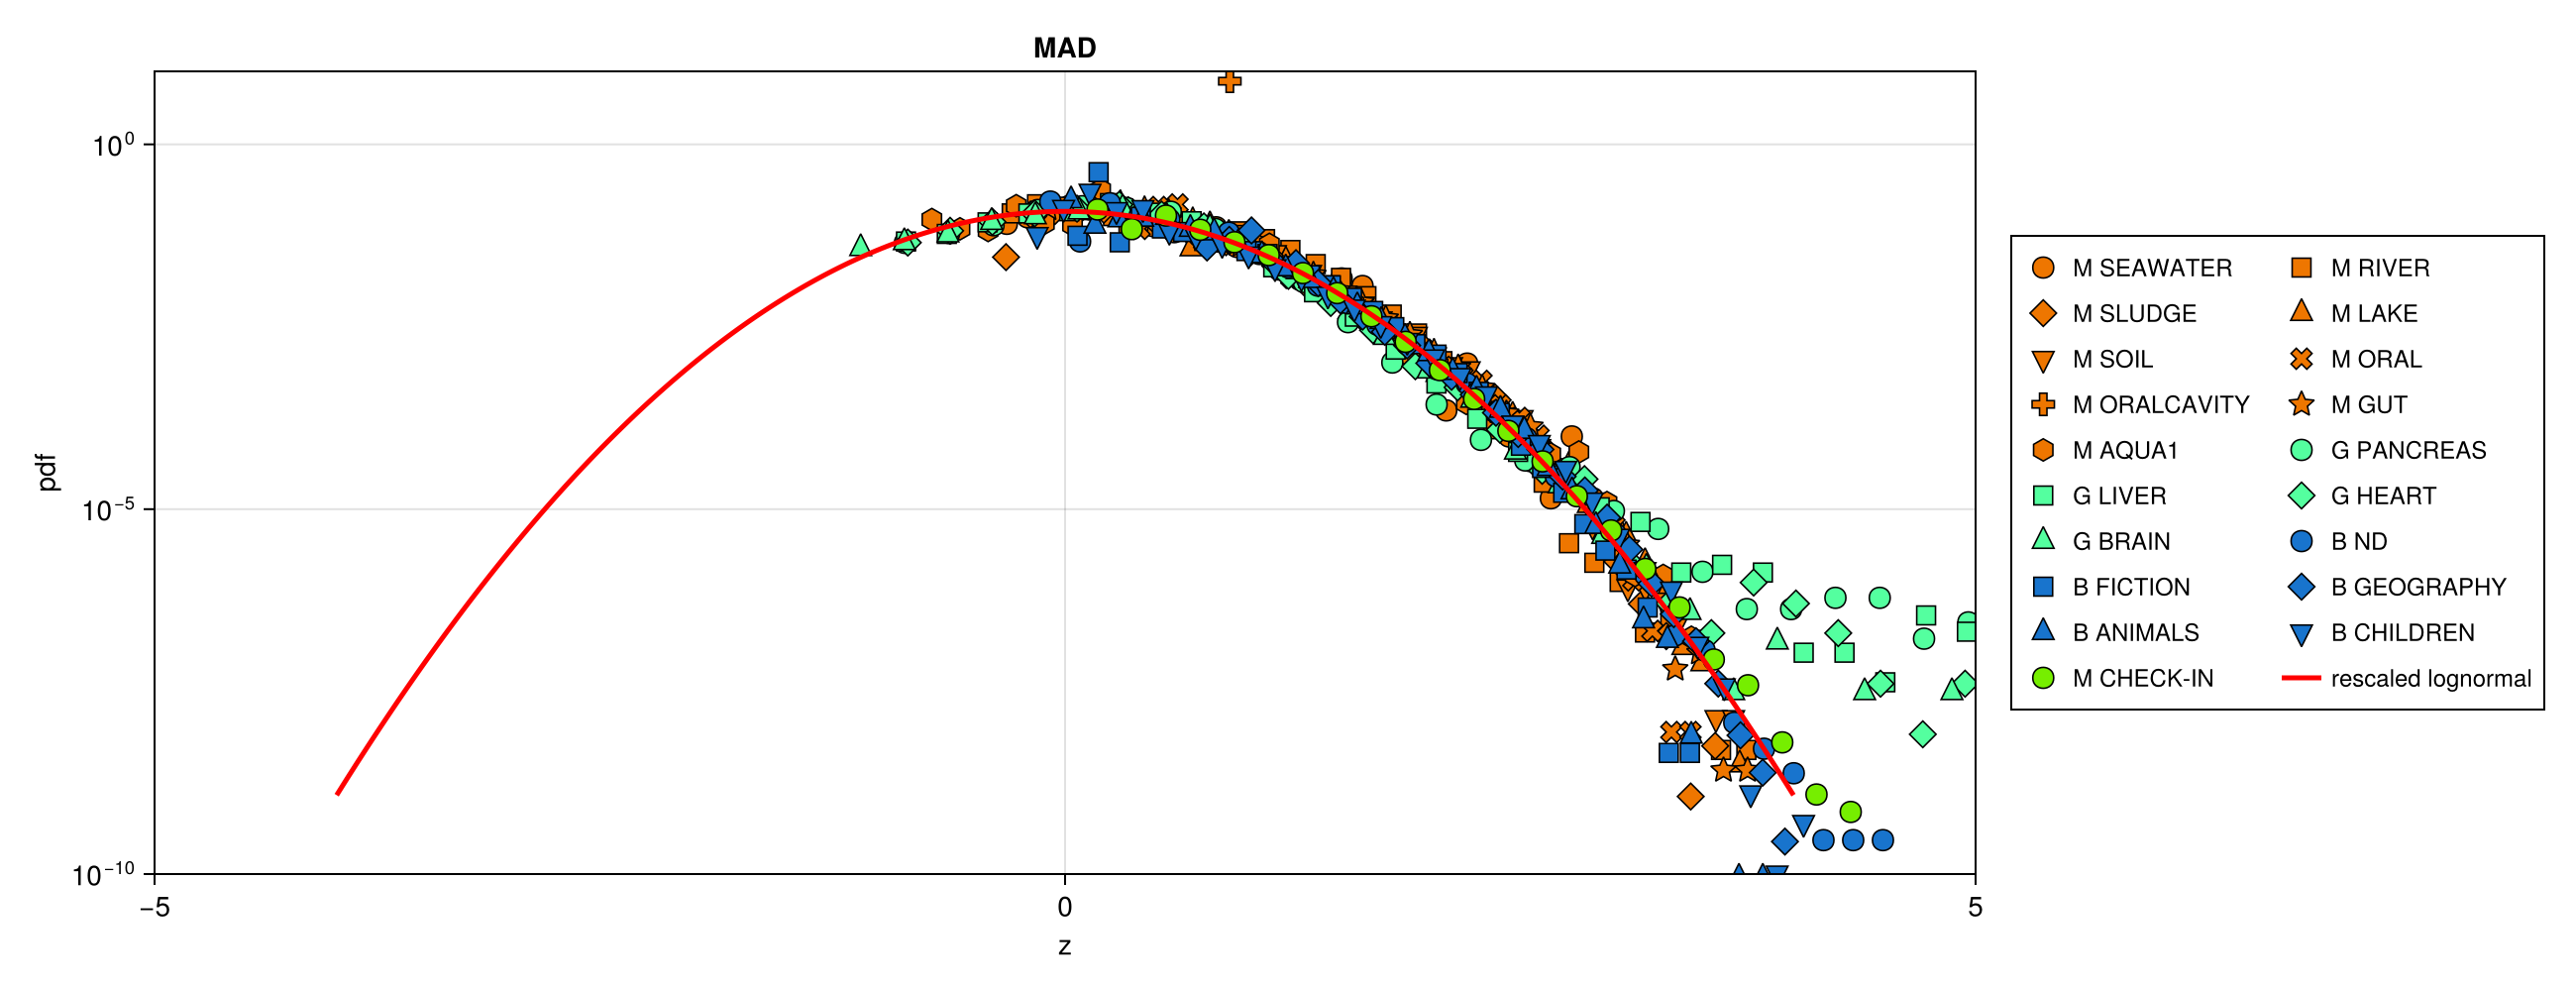

CairoMakie.Screen{IMAGE}


In [28]:
display(fig)

In [29]:
save("./Images/MAD_cutoff.png", fig)

# Reads distribution

In [6]:
# out = Utils.reads_distribution(NULL_MODEL; bins=30, plot=false, verbose=true, save=true, filename="./Data/reads_d/null");

In [42]:
@load "./Data/reads_d/microbiome.jld2" reads_out
microbiome_rd = deepcopy(reads_out)

@load "./Data/reads_d/genetic.jld2" reads_out
genetic_rd = deepcopy(reads_out)

@load "./Data/reads_d/books.jld2" reads_out
books_rd = deepcopy(reads_out)

@load "./Data/reads_d/mobility.jld2" reads_out
mobility_rd = deepcopy(reads_out)

@load "./Data/reads_d/null.jld2" reads_out
null_rd = deepcopy(reads_out)

reads_out = nothing
RDs = [microbiome_rd, genetic_rd, books_rd, mobility_rd, null_rd];

In [43]:
fig = Figure(size=(1300,500))
ax  = Axis(fig[1, 1];
        yscale=log10, limits=((-5,5),(1e-10,1e1)),
        xlabel = "z", ylabel = "pdf", 
        title = "Reads Distribution")

# markers and colors
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :white)

# Prepare separate lists for data and theory
data_plots   = Plot[]       # will hold scatter objects
data_labels  = String[]
env_labels = ["M", "G", "B", "M", "Null"]

for (j,rd) in enumerate(RDs)
    for (i,key) in enumerate(keys(rd))
        x, y = rd[key]
        sc = scatter!(ax, x, 10 .^ log.(y),
                    label=env_labels[j],
                    color=colors[j],
                    marker=shapes[i],
                    markersize=15,
                    strokewidth = 0.8,
                    strokecolor = :black)
        push!(data_plots, sc)
        push!(data_labels, "$(env_labels[j]) $key")
    end
end

zrange = -4:0.01:4
l3 = lines!(ax, zrange, 10 .^ Utils.lrln(zrange, 1); color=:red, linewidth=2.5, label="")
push!(data_plots, l3); push!(data_labels, "rescaled lognormal")

leg_data = Legend(fig, data_plots, data_labels;
    title        = "Data",
    orientation  = :vertical,
    nbanks = 2,
    # shrink the label and title fonts
    labelsize    = 12,
    titlesize    = 12,
)

fig[1, 2] = leg_data;

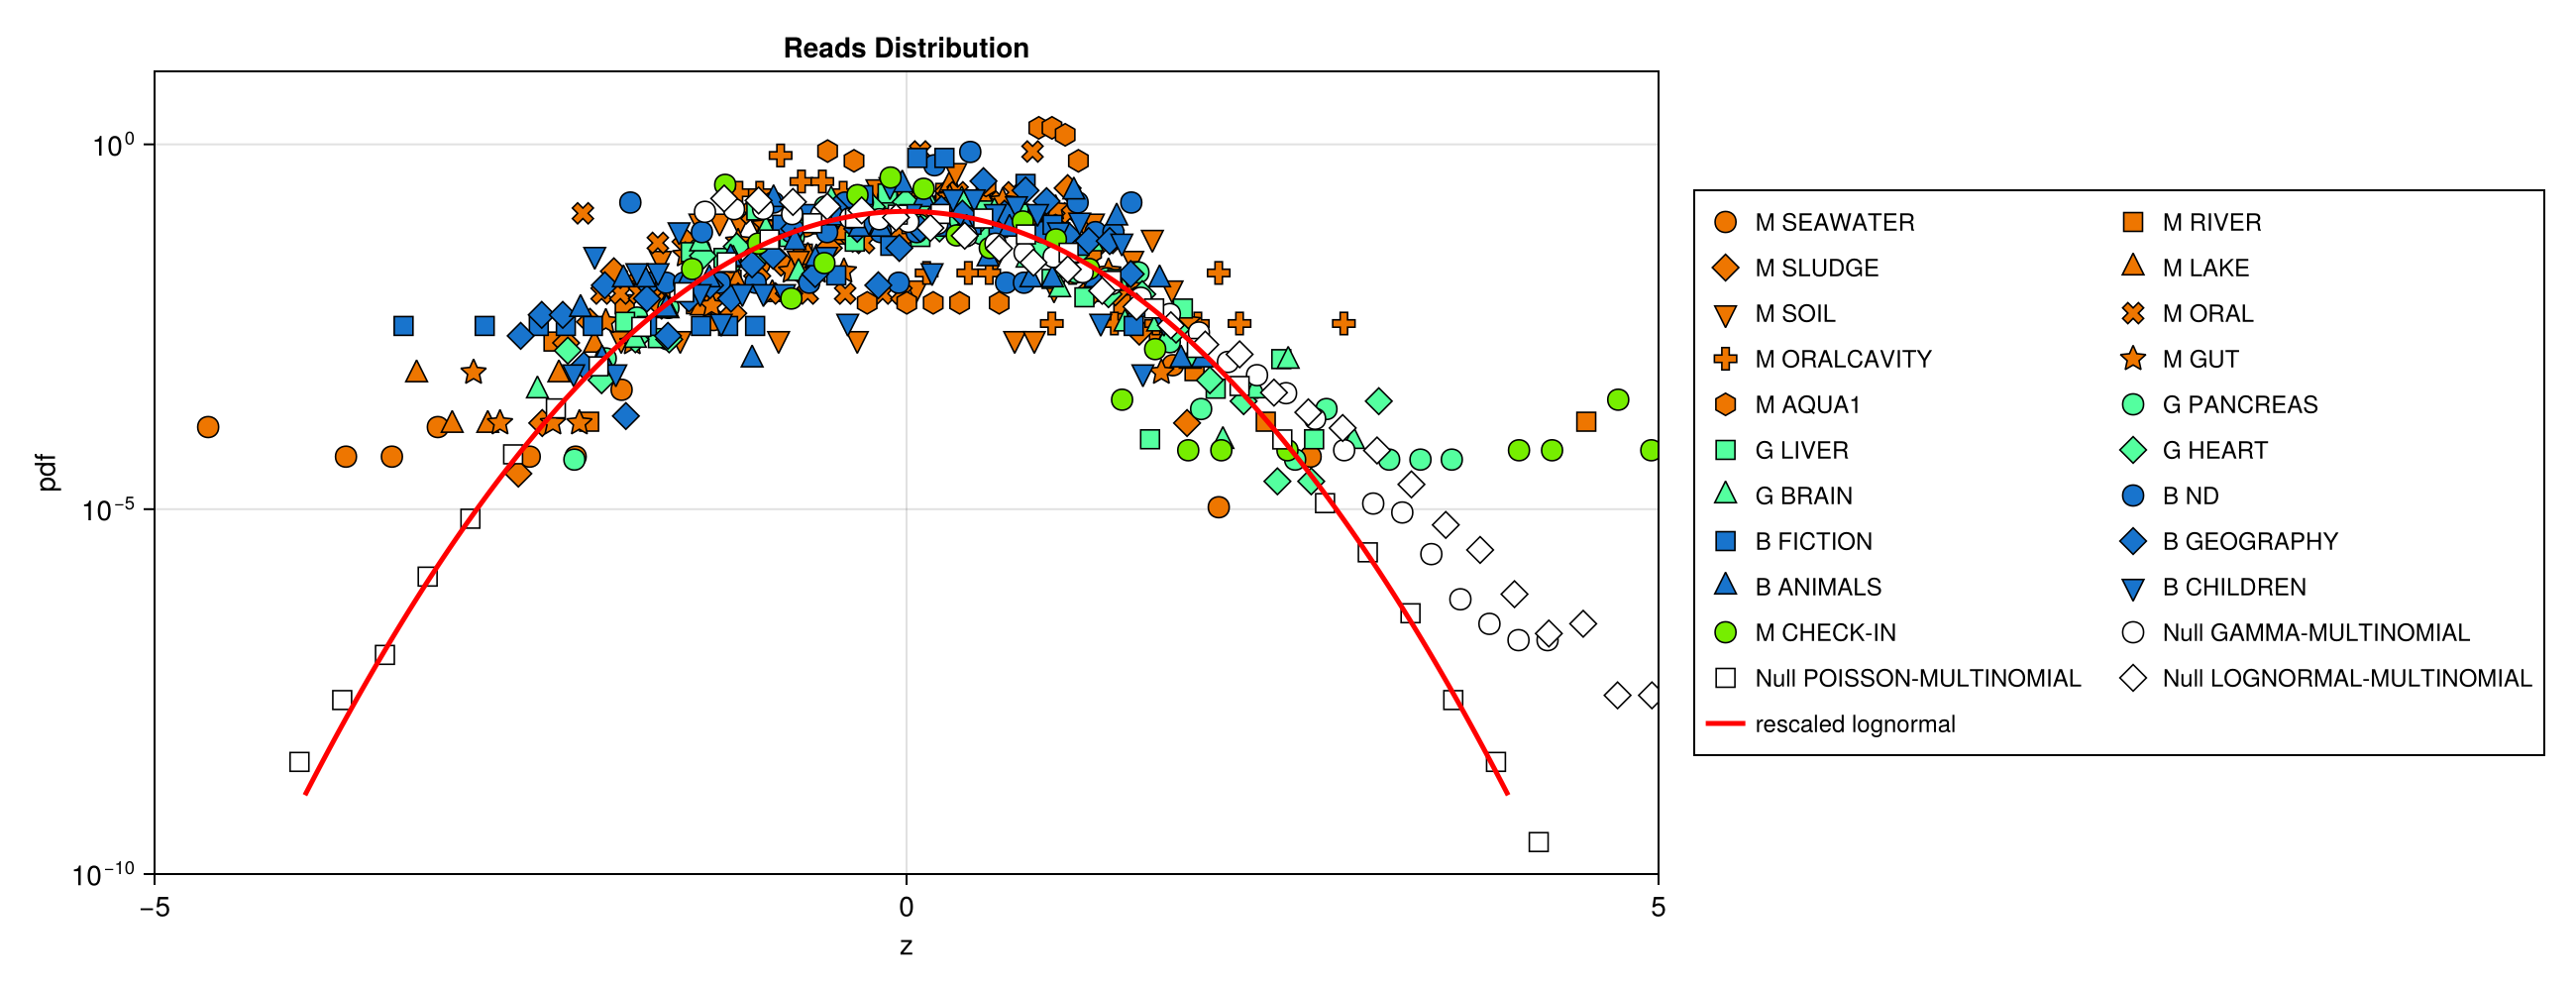

CairoMakie.Screen{IMAGE}


In [44]:
display(fig)

In [45]:
# save("./Images/read_distribution.png", fig)

# AFD

In [11]:
# out = Utils.compute_AFD(NULL_MODEL; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/AFD/null_afd");

In [4]:
@load "./Data/AFD/microbiome_afd.jld2" afd_out
microbiome_afd = deepcopy(afd_out)

@load "./Data/AFD/genetic_afd.jld2" afd_out
genetic_afd = deepcopy(afd_out)

@load "./Data/AFD/books_afd.jld2" afd_out
books_afd = deepcopy(afd_out)

@load "./Data/AFD/mobility_afd.jld2" afd_out
mobility_afd = deepcopy(afd_out)

@load "./Data/AFD/null_afd.jld2" afd_out
null_afd = deepcopy(afd_out)

afd_out = nothing
AFDs = [microbiome_afd, genetic_afd, books_afd, mobility_afd, null_afd];

In [11]:
fig = Figure(size=(1300,500))
ax  = Axis(fig[1, 1];
        yscale=log10, limits=((-10.5,10),(1e-16,1e1)),
        xlabel = "z-score", ylabel = "pdf", 
        title = "AFD")

# markers and colors
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :white)

# Prepare separate lists for data and theory
data_plots   = Plot[]       # will hold scatter objects
data_labels  = String[]
env_labels = ["M", "G", "B", "M", "Null"]

for (j,afd) in enumerate(AFDs)
    for (i,key) in enumerate(keys(afd))
        x, y = afd[key]
        sc = scatter!(ax, x, 10 .^ log.(y),
                    label=env_labels[j],
                    color=colors[j],
                    marker=shapes[i],
                    markersize=15,
                    strokewidth = 0.8,
                    strokecolor = :black)
        push!(data_plots, sc)
        push!(data_labels, "$(env_labels[j]) $key")
    end
end

zrange = -10:0.01:10

l1 = lines!(ax, zrange, 10 .^ Utils.lrg(zrange, 5); color=:red, linewidth=2.5, label="", linestyle=:solid)
push!(data_plots, l1); push!(data_labels, "rescaled gamma")

l2 = lines!(ax, zrange, 10 .^ Utils.lrln(zrange, 1); color=:magenta, linewidth=2.5, label="", linestyle=:dashdot)
push!(data_plots, l2); push!(data_labels, "rescaled lognormal")

l3 = lines!(ax, zrange, 10 .^ Utils.lrig(zrange, 10); color=:cyan, linewidth=2.5, label="", linestyle=:solid)
push!(data_plots, l3); push!(data_labels, "rescaled inv-gamma")

leg_data = Legend(fig, data_plots, data_labels;
    title        = "Data",
    orientation  = :vertical,
    nbanks = 2,
    # shrink the label and title fonts
    labelsize    = 12,
    titlesize    = 12,
)

fig[1, 2] = leg_data;

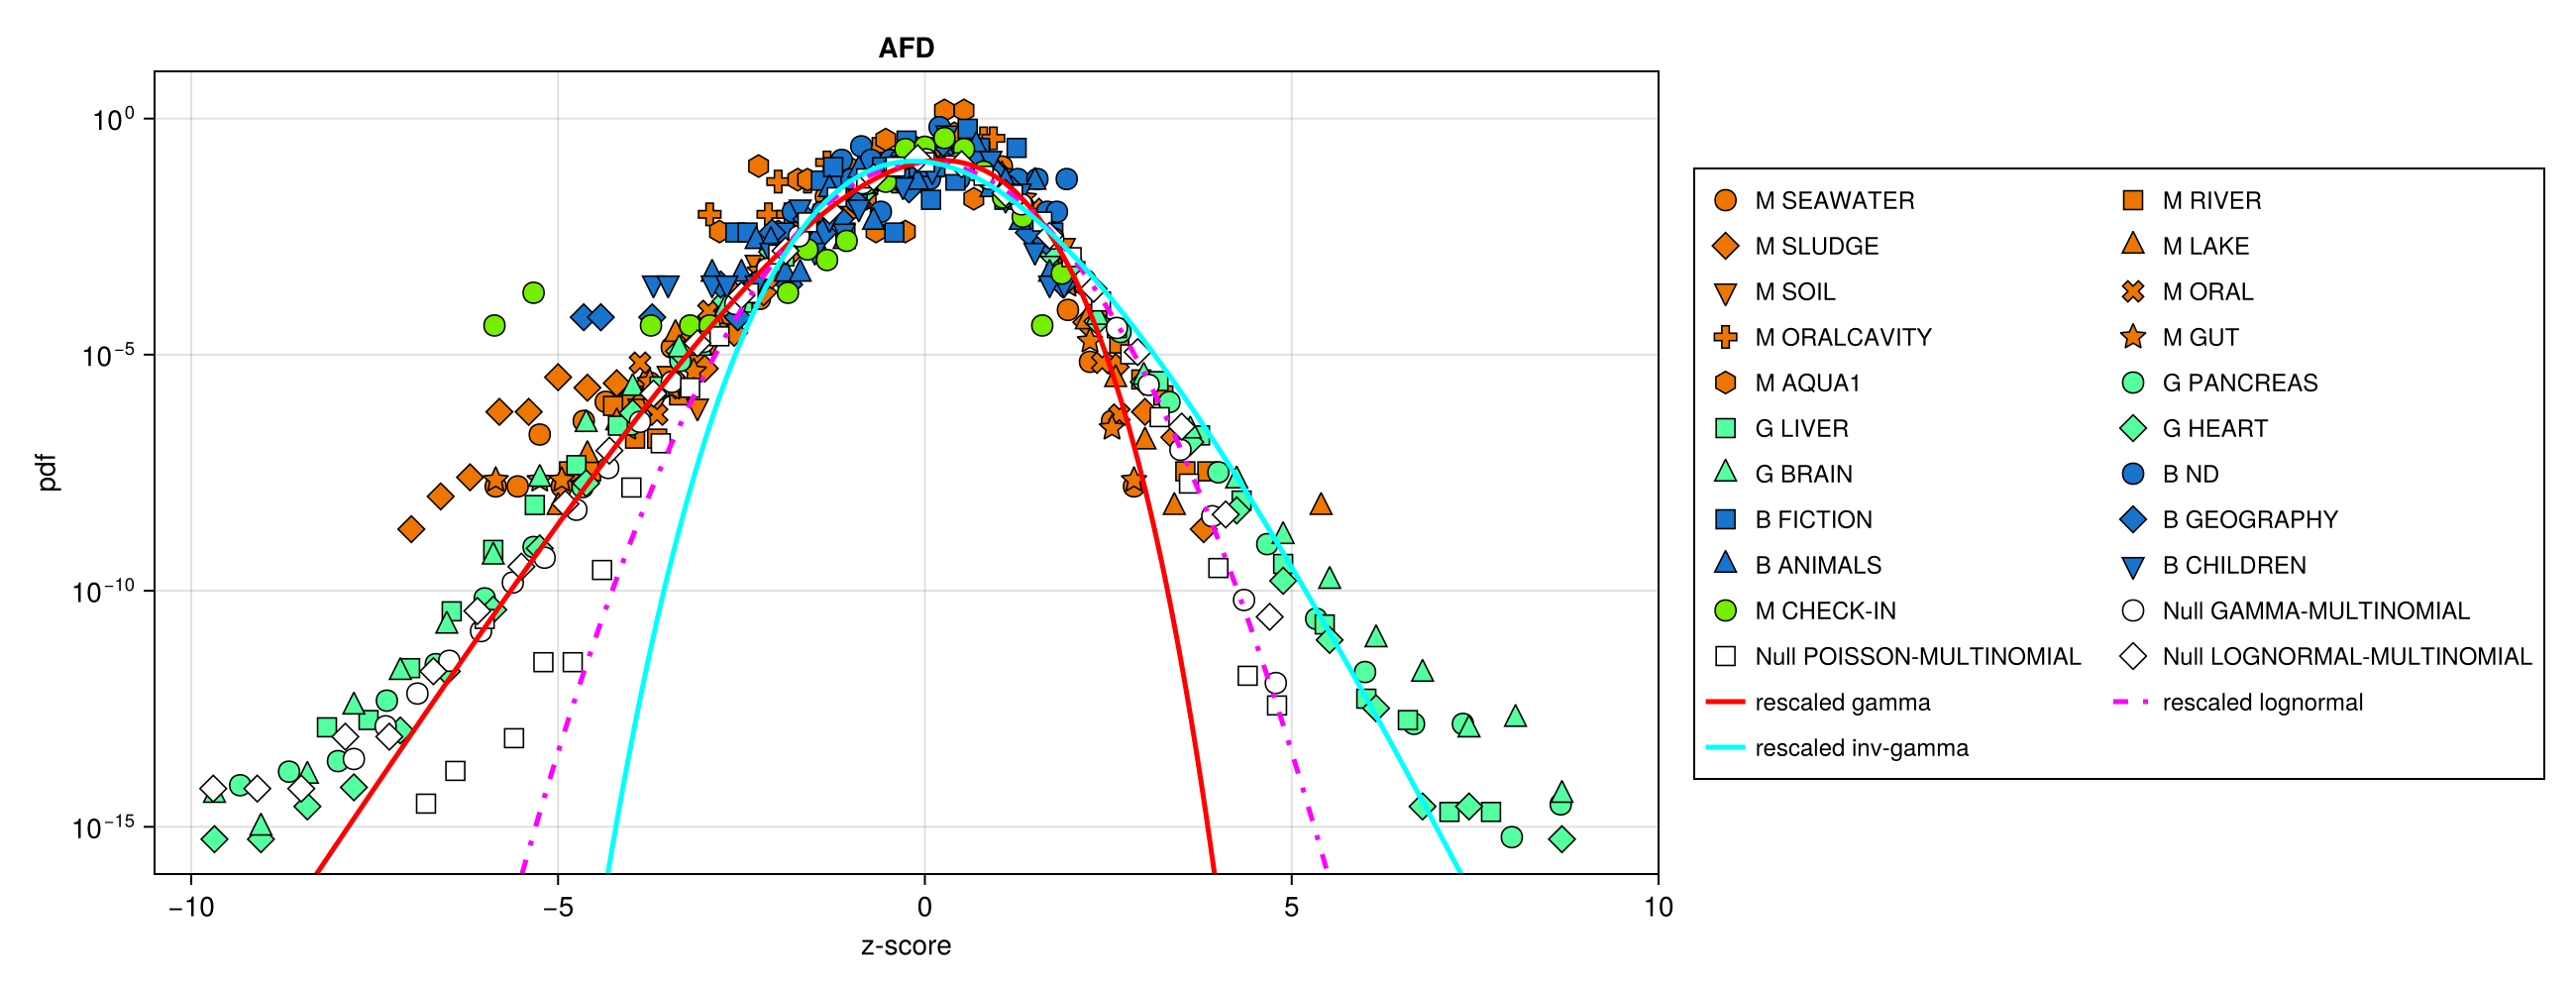

CairoMakie.Screen{IMAGE}


In [12]:
display(fig)

In [44]:
# save("./Images/AFD5.png", fig)

# Taylor's Law

In [39]:
# out = Utils.compute_TL(BOOKS; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/TL/books_tl");
# out = Utils.compute_TL(MOBILITY; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/TL/mobility_tl");
# out = Utils.compute_TL(NULL_MODEL; occ=1, bins=30, plot=false, verbose=true, save=true, filename="./Data/TL/null_tl");

In [8]:
@load "./Data/TL/microbiome_tl.jld2" taylor_out
microbiome_tl = deepcopy(taylor_out)

@load "./Data/TL/genetic_tl.jld2" taylor_out
genetic_tl = deepcopy(taylor_out)

@load "./Data/TL/books_tl.jld2" taylor_out
books_tl = deepcopy(taylor_out)

@load "./Data/TL/mobility_tl.jld2" taylor_out
mobility_tl = deepcopy(taylor_out)

@load "./Data/TL/null_tl.jld2" taylor_out
null_tl = deepcopy(taylor_out)

taylor_out = nothing
TLs = [microbiome_tl, genetic_tl, books_tl, mobility_tl, null_tl];

In [36]:
fig = Figure(size=(1300,500))
ax  = Axis(fig[1, 1];
        limits=((-17,-2),(-38,0)),
        xlabel = "log(μ)", ylabel = "log(σ^2)", 
        title = "Taylor's Law")

# markers and colors
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :white)

# Prepare separate lists for data and theory
data_plots   = Plot[]       # will hold scatter objects
data_labels  = String[]
env_labels = ["M", "G", "B", "M", "Null"]

for (j,tl) in enumerate(TLs)
    for (i,key) in enumerate(keys(tl))
        x, y = tl[key]
        sc = scatter!(ax, x, y,
                    label=env_labels[j],
                    color=colors[j],
                    marker=shapes[i],
                    markersize=15,
                    strokewidth = 0.8,
                    strokecolor = :black)
        push!(data_plots, sc)
        push!(data_labels, "$(env_labels[j]) $key")
    end
end

xrange = -18:0.01:0
l1 = lines!(ax, xrange, 2 .* xrange; color=:red, linewidth=2.5, label="", linestyle=:solid)
push!(data_plots, l1); push!(data_labels, "y = 2x")

leg_data = Legend(fig, data_plots, data_labels;
    title        = "Data",
    orientation  = :vertical,
    nbanks = 2,
    # shrink the label and title fonts
    labelsize    = 12,
    titlesize    = 12,
)

fig[1, 2] = leg_data;

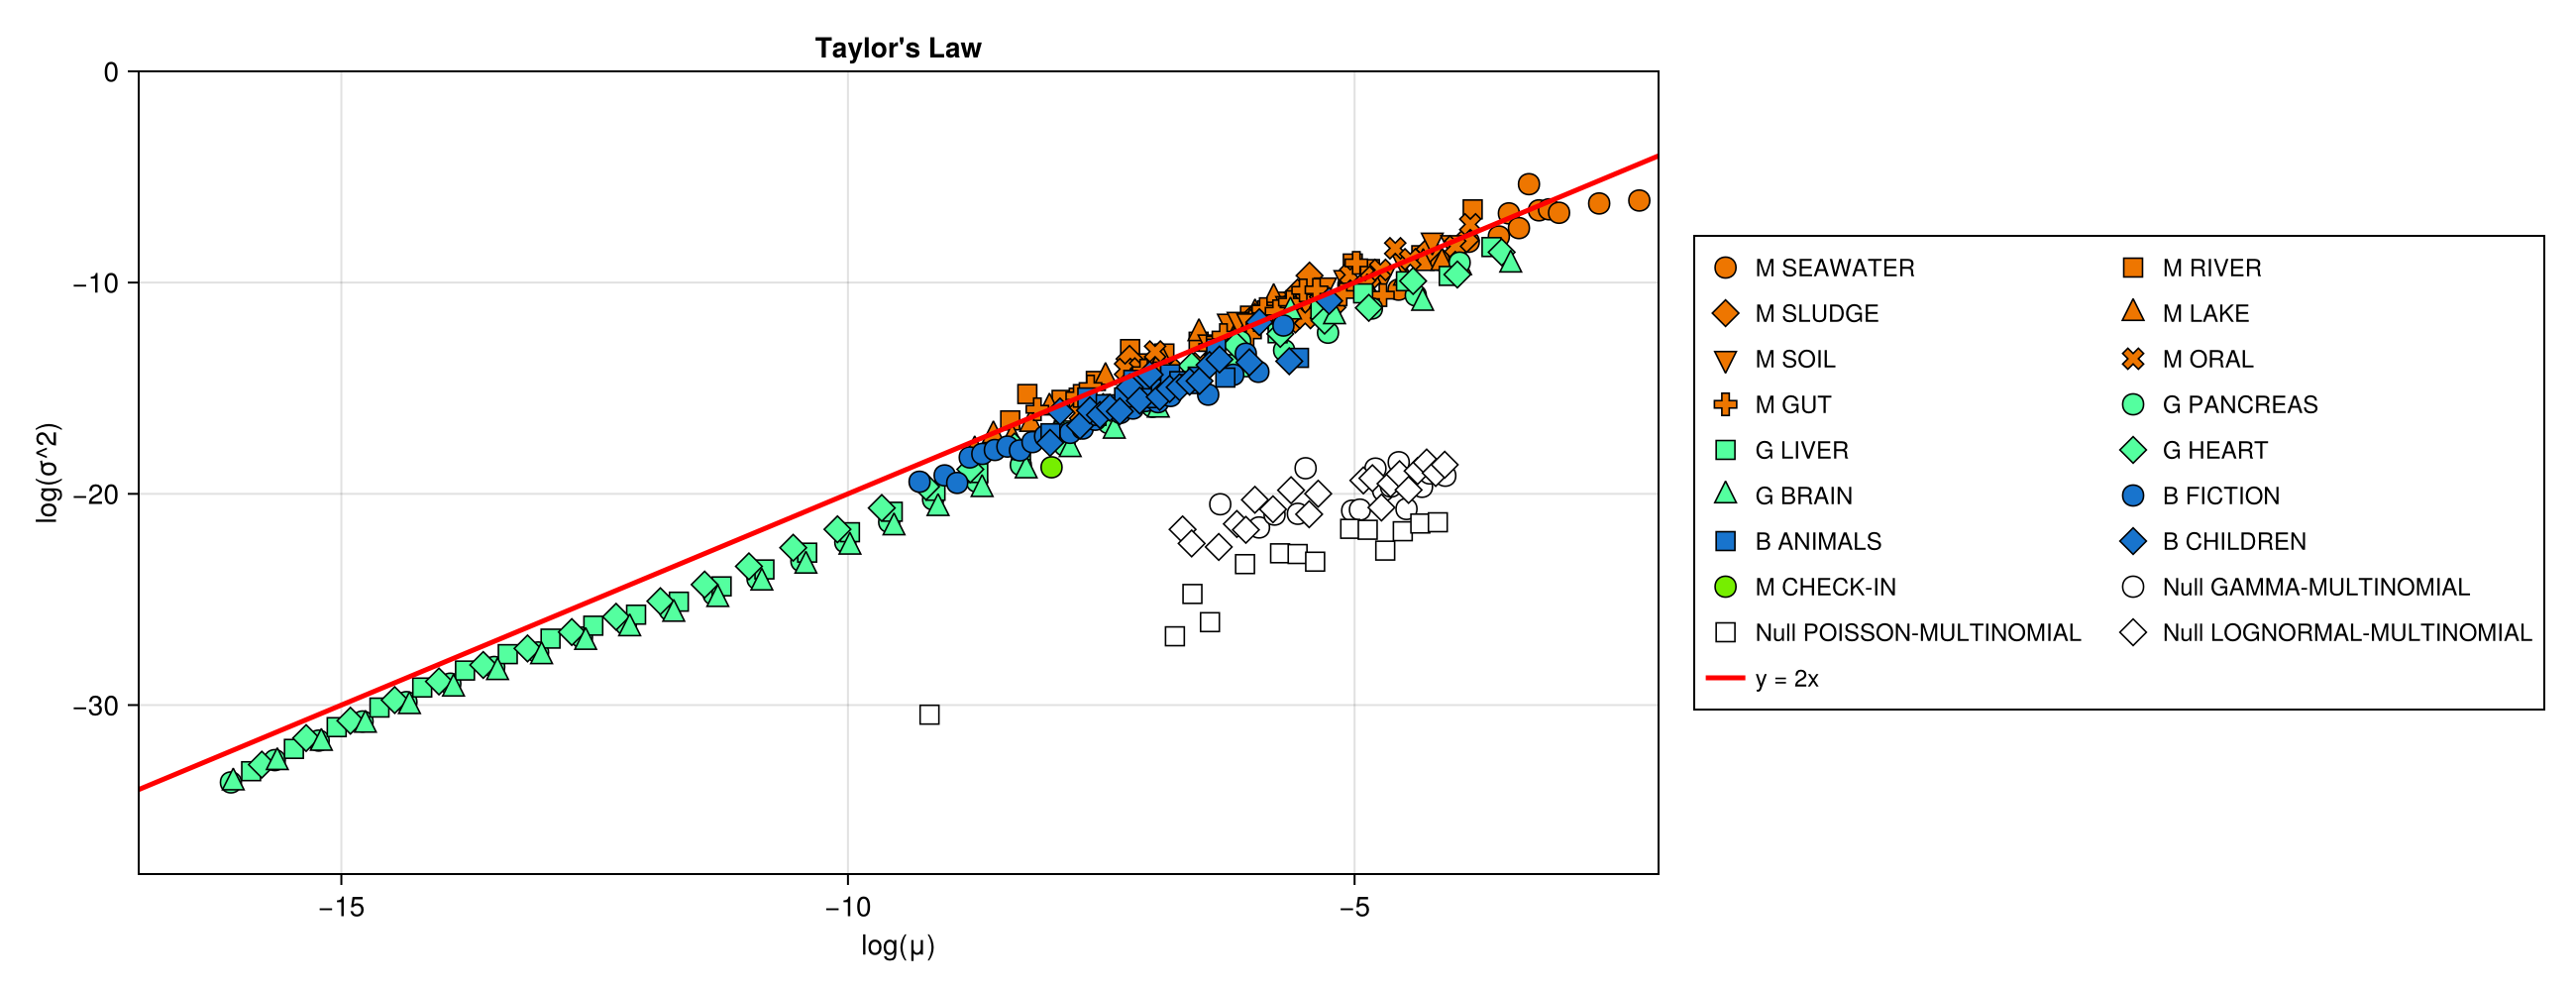

CairoMakie.Screen{IMAGE}


In [37]:
display(fig)

In [38]:
# save("./Images/TL5.png", fig)